# Growth Features

By Wildan

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import PIL
from PIL import GimpGradientFile

In [105]:
df = pd.read_csv('../../data/abis_cleaning.csv')
df.head()

,video_id,video_title,waktu_publikasi_video,duration,engaged_views,estimated_adsense_revenue_idr,subscriber_yang_diperoleh,subscriber_yang_hilang,suka,tidak_suka,...,ts1_views,ts2_views,ts3_views,ts4_views,upload_time_wib,average_view_duration_sec,is_viral,watch_time_hours_log,engaged_views_log,views_log
0,jkL6Ii5d4hI,SURPRISE! PASUKAN CHECHNYA SIAP TEMPUR BELA IN...,"May 23, 2025",541.0,436273,1005756.693,1420,76,4716,102,...,184892.0,235050.0,249236.0,283708.0,11:15:06,217,1,10.179752,12.986026,12.986026
1,mIeRGD4KT-A,BUNGKAM MULUT AUSTRALIA! RUSIA ANCAM AUSTRALIA...,"May 7, 2025",540.0,379446,1079707.160,1447,67,4325,75,...,139769.0,169366.0,202409.0,298861.0,09:15:06,229,1,10.094310,12.846470,12.846470
2,XCRg3dGQqd8,GEMPUR JEPANG & KOREA‼️ QRIS INDONESIA BIKIN M...,"May 3, 2025",637.0,348698,1280760.404,1059,81,4500,75,...,205823.0,244293.0,264188.0,293882.0,16:15:06,203,1,9.889986,12.761964,12.761964
3,ej_cl5Ixy8I,RAJA JIPLAK ASEAN KALAH TELAK! PAMERAN INDONES...,"May 3, 2025",530.0,332566,950857.736,690,52,3755,76,...,150161.0,177797.0,198004.0,224264.0,09:15:06,172,1,9.679255,12.714597,12.714597
4,_a-qHV6XZzE,"AUSTRALIA ANCAM PERANG INDONESIA, JIKA RUSIA B...","May 12, 2025",540.0,329562,888987.046,946,52,2970,85,...,165552.0,203165.0,227907.0,267714.0,12:30:06,223,1,9.924137,12.705523,12.705523


## EDA 

In [106]:
df.tail()

,video_id,video_title,waktu_publikasi_video,duration,engaged_views,estimated_adsense_revenue_idr,subscriber_yang_diperoleh,subscriber_yang_hilang,suka,tidak_suka,...,ts1_views,ts2_views,ts3_views,ts4_views,upload_time_wib,average_view_duration_sec,is_viral,watch_time_hours_log,engaged_views_log,views_log
2340,ETRPFXgUb4w,TITISAN KHAMENEI BANGKIT! KEMUNCULAN MOJTABA G...,"Mar 15, 2026",690.0,444,4076.156,0,1,16,1,...,200.0,222.0,234.0,235.0,10:15:06,246,0,3.446375,6.098074,6.098074
2341,TydHb9EmSi0,AS INCAR URANIUM‼️ TRUMP SIAGAKAN PASUKAN DARA...,"Mar 9, 2026",540.0,411,3008.003,0,0,12,2,...,235.0,280.0,301.0,305.0,13:15:06,200,0,3.173364,6.021023,6.021023
2342,5wXpFi5pwy8,DI AMBANG KIAMAT? Kenapa Negara Arab Gemetar J...,"Feb 27, 2026",263.0,284,1403.836,0,0,4,0,...,86.0,93.0,94.0,94.0,11:45:06,85,0,2.045303,5.652489,5.652489
2343,PxldrK_BBH8,"GEGERKAN ASEAN‼️ INDONESIA RESMI JADI ""RAJA BA...","Feb 4, 2026",690.0,41,102.003,0,0,0,0,...,41.0,41.0,41.0,41.0,11:00:06,197,0,1.177269,3.737670,3.737670
2344,Px-jSTvss5g,ISRAEL TERBAKAR! IRAN LUNCURKAN RUDAL KHORRAMS...,"Mar 7, 2026",540.0,19,87.908,0,0,0,0,...,19.0,19.0,19.0,19.0,10:15:06,160,0,0.615023,2.995732,2.995732


In [107]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2345 entries, 0 to 2344
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   video_id                            2345 non-null   str    
 1   video_title                         2345 non-null   str    
 2   waktu_publikasi_video               2345 non-null   str    
 3   duration                            2345 non-null   float64
 4   engaged_views                       2345 non-null   int64  
 5   estimated_adsense_revenue_idr       2345 non-null   float64
 6   subscriber_yang_diperoleh           2345 non-null   int64  
 7   subscriber_yang_hilang              2345 non-null   int64  
 8   suka                                2345 non-null   int64  
 9   tidak_suka                          2345 non-null   int64  
 10  komentar_ditambahkan                2345 non-null   int64  
 11  average_percentage_viewed_pct       2345 non-null   fl

In [108]:
df.shape

(2345, 42)

In [109]:
df.columns

Index(['video_id', 'video_title', 'waktu_publikasi_video', 'duration',
       'engaged_views', 'estimated_adsense_revenue_idr',
       'subscriber_yang_diperoleh', 'subscriber_yang_hilang', 'suka',
       'tidak_suka', 'komentar_ditambahkan', 'average_percentage_viewed_pct',
       'youtube_premium_idr', 'watch_page_ads_idr', 'youtube_ad_revenue_idr',
       'ad_impressions', 'playback_based_cpm_idr', 'cpm_idr',
       'estimated_monetized_playbacks', 'rpm_idr',
       'youtube_premium_watch_time_hours', 'youtube_premium_views',
       'end_screen_elements_shown', 'end_screen_element_clicks', 'views',
       'watch_time_hours', 'subscribers', 'estimated_revenue_idr',
       'impressions', 'impressions_click_through_rate_pct', 'judul',
       'tanggal_upload', 'ts1_views', 'ts2_views', 'ts3_views', 'ts4_views',
       'upload_time_wib', 'average_view_duration_sec', 'is_viral',
       'watch_time_hours_log', 'engaged_views_log', 'views_log'],
      dtype='str')

## Pengecekan kembali kualitas data

In [110]:
df.isnull().sum()

video_id                              0
video_title                           0
waktu_publikasi_video                 0
duration                              0
engaged_views                         0
estimated_adsense_revenue_idr         0
subscriber_yang_diperoleh             0
subscriber_yang_hilang                0
suka                                  0
tidak_suka                            0
komentar_ditambahkan                  0
average_percentage_viewed_pct         0
youtube_premium_idr                   0
watch_page_ads_idr                    0
youtube_ad_revenue_idr                0
ad_impressions                        0
playback_based_cpm_idr                0
cpm_idr                               0
estimated_monetized_playbacks         0
rpm_idr                               0
youtube_premium_watch_time_hours      0
youtube_premium_views                 0
end_screen_elements_shown             0
end_screen_element_clicks             0
views                                 0


In [111]:
df.duplicated().sum()

np.int64(0)

* Data yang digunakan aman dan siap di analisis atau EDA

## Slicing data sehingga menghasilkan matrix yang digunakan saja untuk fitur jobdesk saya
### Adapun matrix yang saya gunakan adalah:
- video_id	
- pload_time_wib	
- views	watch_time_hours	
- subscribers	
- is_viral	
- impressions	
- impressions_click_through_rate_pct	
- suka	
- tidak_suka	
- komentar_ditambahkan	
- engaged_views	
- average_percentage_viewed_pct	
- average_view_duration_sec	
- subscriber_yang_diperoleh	
- subscriber_yang_hilang	
- ts1_views, ts2_views,	ts3_views, ts4_views

In [112]:
kolom_pilihan = [
    'video_id',                        
    'upload_time_wib',                 
    'views',
    'watch_time_hours', 
    'subscribers', 
    'is_viral',
    'impressions', 
    'impressions_click_through_rate_pct',
    'suka', 
    'tidak_suka', 
    'komentar_ditambahkan',
    'engaged_views', 
    'average_percentage_viewed_pct', 
    'average_view_duration_sec',
    'subscriber_yang_diperoleh', 
    'subscriber_yang_hilang',
    'ts1_views', 'ts2_views', 'ts3_views', 'ts4_views'
]
df_sliced = df[kolom_pilihan].copy()
print(f"Jumlah kolom sebelum slicing: {df.shape[1]}")
print(f"Jumlah kolom setelah slicing: {df_sliced.shape[1]}")
df_sliced.head(3)

Jumlah kolom sebelum slicing: 42
Jumlah kolom setelah slicing: 20


,video_id,upload_time_wib,views,watch_time_hours,subscribers,is_viral,impressions,impressions_click_through_rate_pct,suka,tidak_suka,komentar_ditambahkan,engaged_views,average_percentage_viewed_pct,average_view_duration_sec,subscriber_yang_diperoleh,subscriber_yang_hilang,ts1_views,ts2_views,ts3_views,ts4_views
0,jkL6Ii5d4hI,11:15:06,436273.0,26362.9304,1344,1,3209146,11.89,4716,102,793,436273,40.21,217,1420,76,184892.0,235050.0,249236.0,283708.0
1,mIeRGD4KT-A,09:15:06,379446.0,24203.8942,1380,1,3144626,10.64,4325,75,1418,379446,42.52,229,1447,67,139769.0,169366.0,202409.0,298861.0
2,XCRg3dGQqd8,16:15:06,348698.0,19730.7862,978,1,2646365,10.72,4500,75,873,348698,31.98,203,1059,81,205823.0,244293.0,264188.0,293882.0


## EDA Untuk setiap Fitur dan mengerjakan fitur

### 1. Daily Growth Rate


* daily_growth_rate = (views_today - views_yesterday) / views_yesterday * 100

#### EDA

1. Melakukan pengecekan untuk ts4_views apakah lebiih besar daripada views karena akan anomali jika tidak begitu

In [113]:
anomali_cek = df_sliced['ts4_views'] > df_sliced['views']
df_anomali = df_sliced[anomali_cek]
print(f"Jumlah baris anomali (ts4_views > total views): {len(df_anomali)}")

Jumlah baris anomali (ts4_views > total views): 0


* Menghitung fitur daily_growth_rate

In [114]:
df_sliced['ts1_safe'] = df_sliced['ts1_views'].replace(0, np.nan)
df_sliced['ts2_safe'] = df_sliced['ts2_views'].replace(0, np.nan)
df_sliced['ts3_safe'] = df_sliced['ts3_views'].replace(0, np.nan)
# Menghitung persentase pertumbuhan antar periode
df_sliced['growth_1_to_2'] = ((df_sliced['ts2_views'] - df_sliced['ts1_views']) / df_sliced['ts1_safe']) * 100
df_sliced['growth_2_to_3'] = ((df_sliced['ts3_views'] - df_sliced['ts2_views']) / df_sliced['ts2_safe']) * 100
df_sliced['growth_3_to_4'] = ((df_sliced['ts4_views'] - df_sliced['ts3_views']) / df_sliced['ts3_safe']) * 100
# Jika ada NaN (karena awalnya dibagi 0), kembalikan nilainya menjadi 0% pertumbuhan
kolom_growth = ['growth_1_to_2', 'growth_2_to_3', 'growth_3_to_4']
df_sliced[kolom_growth] = df_sliced[kolom_growth].fillna(0)
# Buang kolom sementara (_safe) agar memori tetap bersih
df_sliced = df_sliced.drop(columns=['ts1_safe', 'ts2_safe', 'ts3_safe'])


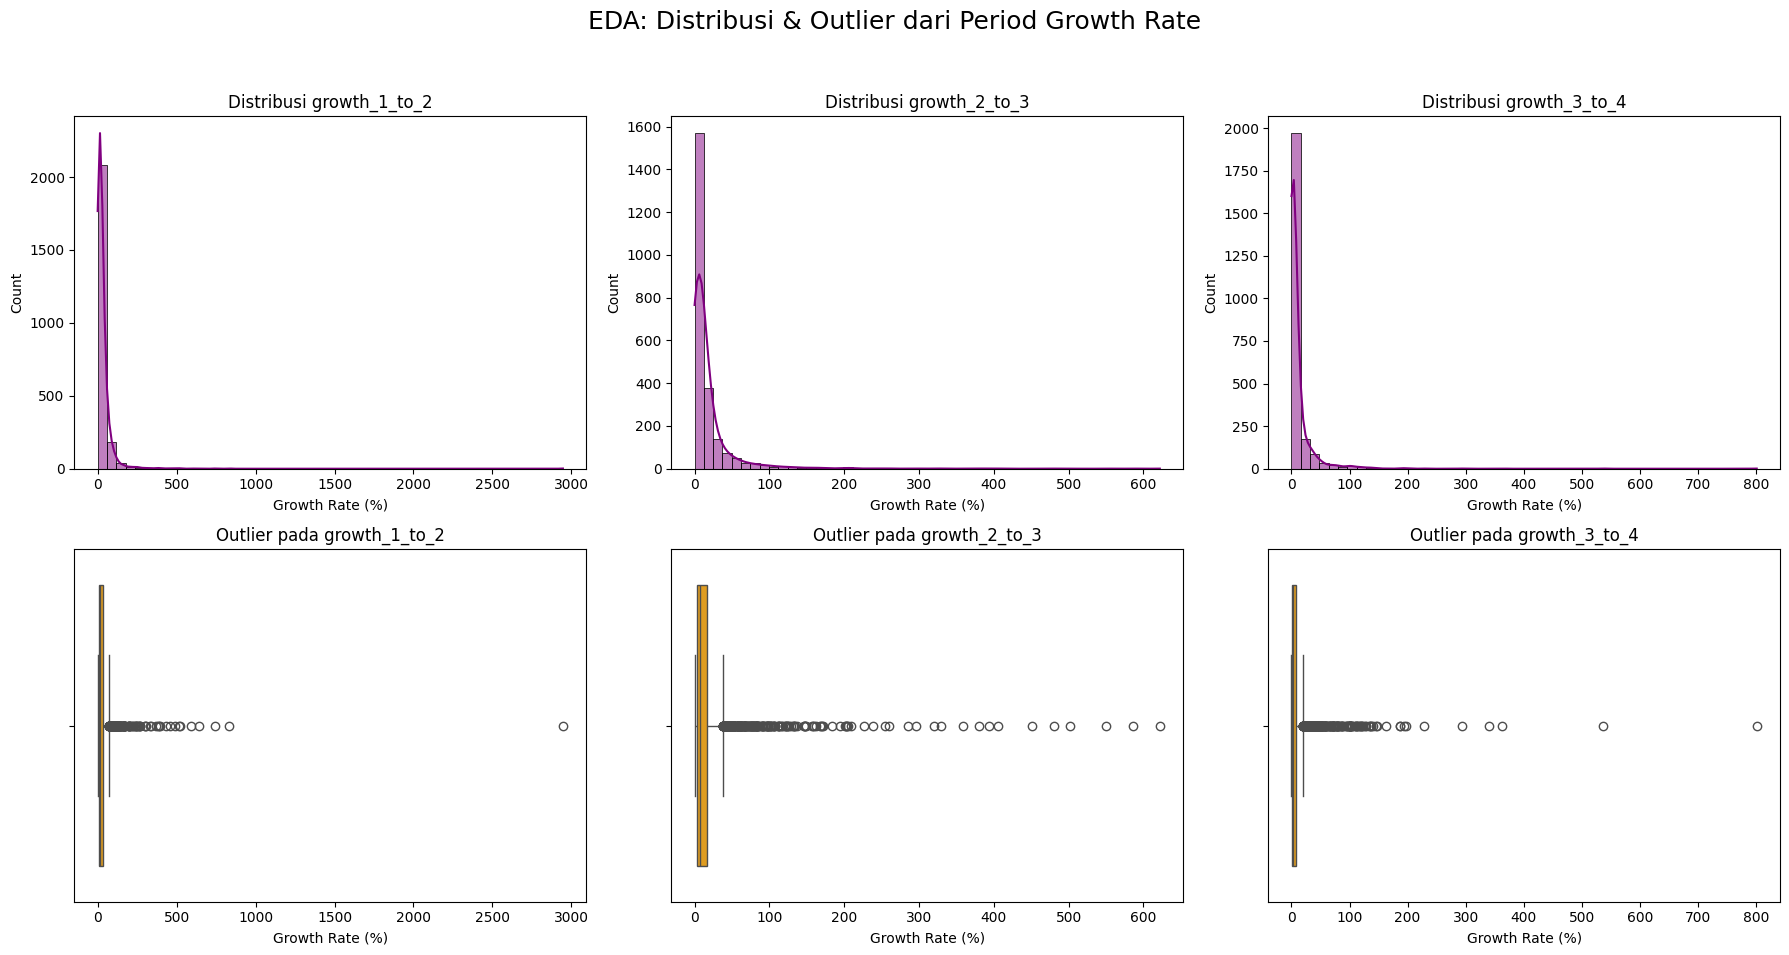

Statistik Deskriptif Growth Rate:


,growth_1_to_2,growth_2_to_3,growth_3_to_4
count,2345.000000,2345.000000,2345.000000
mean,31.449786,18.493415,11.038237
std,79.371105,42.291957,30.964834
min,0.000000,0.000000,0.000000
25%,8.068322,2.930999,1.018798
50%,16.054268,6.801008,2.618182
75%,33.363681,16.852540,8.402900
max,2946.603099,621.866029,801.387316


In [115]:
 
# TAHAP 3: EDA (Visualisasi Histogram & Boxplot)
# =====================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA: Distribusi & Outlier dari Period Growth Rate', fontsize=18)
for i, col in enumerate(kolom_growth):
    # Baris atas: Histogram & KDE (Melihat sebaran data)
    sns.histplot(df_sliced[col], bins=50, kde=True, ax=axes[0, i], color='purple')
    axes[0, i].set_title(f'Distribusi {col}')
    axes[0, i].set_xlabel('Growth Rate (%)')
    
    # Baris bawah: Boxplot (Melihat Outlier ekstrem)
    sns.boxplot(x=df_sliced[col], ax=axes[1, i], color='orange')
    axes[1, i].set_title(f'Outlier pada {col}')
    axes[1, i].set_xlabel('Growth Rate (%)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
# Menampilkan Statistik Deskriptif Growth Rate
print("Statistik Deskriptif Growth Rate:")
display(df_sliced[kolom_growth].describe())


### Hasil analisis:
* Tren Penurunan Alami:
- Rata-rata growth_1_to_2 (H+1 ke H+3 adalah 31.4%. Ini adalah masa di mana YouTube sedang banyak merekomendasikan video baru ke subscriber.)
- Kemudian melemah di growth_2_to_3 menjadi 18.5%, dan semakin turun di growth_3_to_4 menjadi 11.0%.
- Dataset siap untuk digunakan

* Distribusi Sangat Menjulur ke Kanan (Right-Skewed):
- Melihat grafik histogram yang menumpuk di kiri, artinya mayoritas video memiliki pertumbuhan yang standar (di bawah 50%).
- Melihat nilai Max yang mencapai 2946% dan banyaknya titik outlier di Boxplot adalah bukti adanya video-video yang viral.
- Outlier sih tapi saya sudah tanya di AI katanya gausah di log_transform karena "tu adalah keputusan yang sangat bijak dan preventif (sedia payung sebelum hujan). Jika Anda nanti secara tidak sengaja mencoba mencoba algoritma Regresi atau Neural Network, model Anda tidak akan langsung hancur."


 

In [116]:
df_sliced[['video_id', 'growth_1_to_2', 'growth_2_to_3', 'growth_3_to_4']].head()


,video_id,growth_1_to_2,growth_2_to_3,growth_3_to_4
0,jkL6Ii5d4hI,27.128269,6.035312,13.831068
1,mIeRGD4KT-A,21.175654,19.509819,47.652031
2,XCRg3dGQqd8,18.690817,8.143909,11.239723
3,ej_cl5Ixy8I,18.404246,11.365209,13.262358
4,_a-qHV6XZzE,22.719750,12.178279,17.466335


## 2. Subscriber Net
subscriber_net = subscribers_gained - subscribers_lost

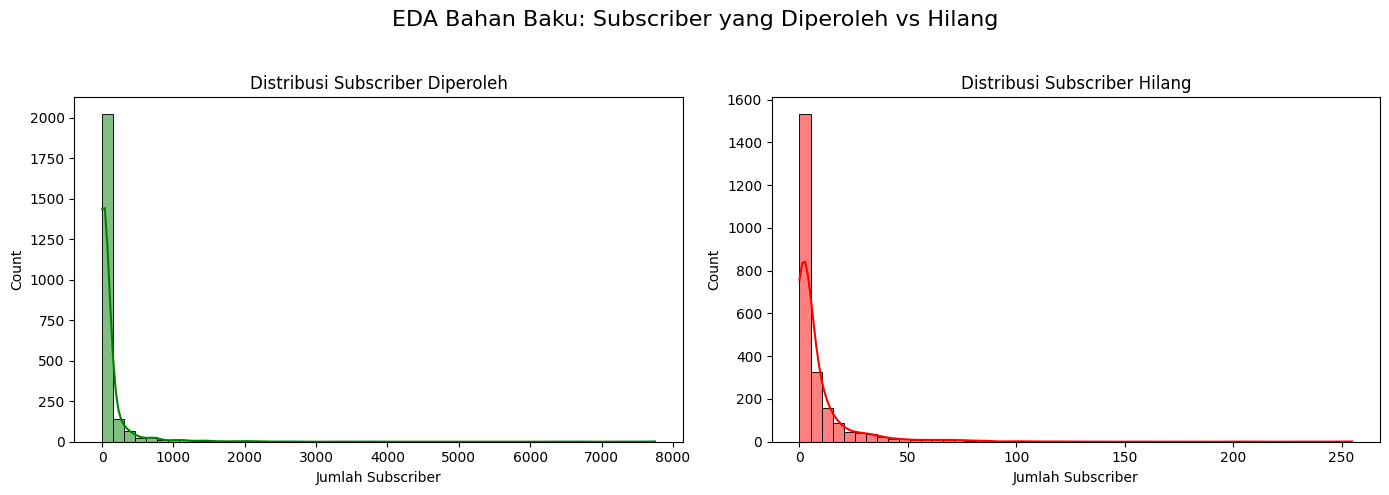

In [117]:
# =====================================================================
# TAHAP 1: EDA BAHAN BAKU (Subscribers Diperoleh vs Hilang)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA Bahan Baku: Subscriber yang Diperoleh vs Hilang', fontsize=16)
# Histogram Subscriber Diperoleh
sns.histplot(df_sliced['subscriber_yang_diperoleh'], bins=50, kde=True, ax=axes[0], color='green')
axes[0].set_title('Distribusi Subscriber Diperoleh')
axes[0].set_xlabel('Jumlah Subscriber')
# Histogram Subscriber Hilang
sns.histplot(df_sliced['subscriber_yang_hilang'], bins=50, kde=True, ax=axes[1], color='red')
axes[1].set_title('Distribusi Subscriber Hilang')
axes[1].set_xlabel('Jumlah Subscriber')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [118]:

# =====================================================================
# TAHAP 2: KALKULASI FEATURE (Subscriber Net)
# =====================================================================
df_sliced['subscriber_net'] = df_sliced['subscriber_yang_diperoleh'] - df_sliced['subscriber_yang_hilang']


### EDA Hasil perhitungan

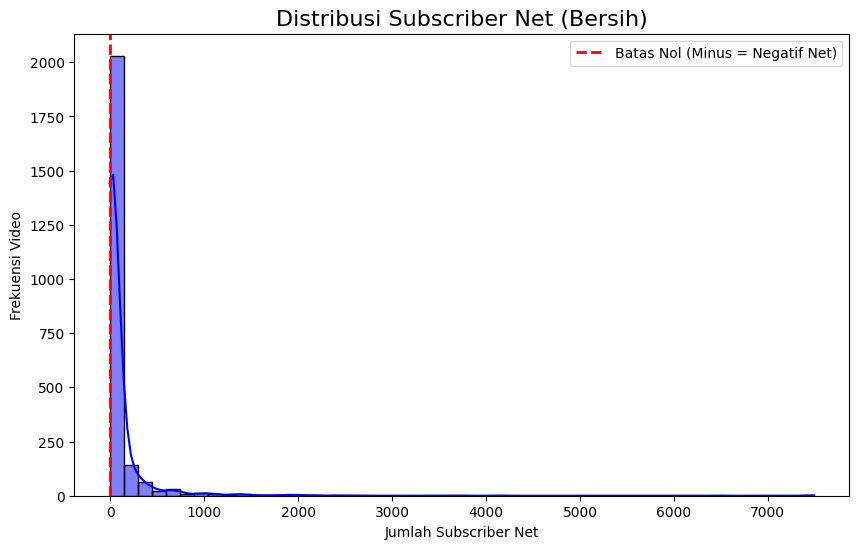

Statistik Deskriptif Subscriber Net:


,subscriber_yang_diperoleh,subscriber_yang_hilang,subscriber_net
count,2345.000000,2345.000000,2345.000000
mean,103.854584,8.381237,95.473348
std,376.501872,16.968969,361.451572
min,0.000000,0.000000,-6.000000
25%,3.000000,1.000000,1.000000
50%,14.000000,3.000000,11.000000
75%,59.000000,8.000000,51.000000
max,7748.000000,255.000000,7493.000000


In [120]:
# =====================================================================
# TAHAP 3: EDA HASIL FITUR (Subscriber Net)
# =====================================================================
plt.figure(figsize=(10, 6))


# Membuat histogram dengan garis batas nol (0)
sns.histplot(df_sliced['subscriber_net'], bins=50, kde=True, color='blue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Batas Nol (Minus = Negatif Net)')
plt.title('Distribusi Subscriber Net (Bersih)', fontsize=16)
plt.xlabel('Jumlah Subscriber Net')
plt.ylabel('Frekuensi Video')
plt.legend()
plt.show()
# Menampilkan angka statistik
print("Statistik Deskriptif Subscriber Net:")
display(df_sliced[['subscriber_yang_diperoleh', 'subscriber_yang_hilang', 'subscriber_net']].describe())


### Kesimpulan :

1. Hampir semua data berada di kanan garis merah (artinya banyak orang yang tidak elfeel dari konten)
2. Mayoritas Video Berada di kisaran 0 hingga ~100 Subscriber Net. Artinya, performa "normal" atau rata-rata harian sebuah video di channel ini menyumbangkan puluhan subscriber bersih.
3. Outlier (Video Viral): Ada ekor panjang yang membentang hingga angka 7000. Ini berarti ada sebagian kecil video yang sangat meledak dan menyumbangkan ribuan subscriber bersih sendirian.

In [122]:
df_sliced.head()

,video_id,upload_time_wib,views,watch_time_hours,subscribers,is_viral,impressions,impressions_click_through_rate_pct,suka,tidak_suka,...,subscriber_yang_diperoleh,subscriber_yang_hilang,ts1_views,ts2_views,ts3_views,ts4_views,growth_1_to_2,growth_2_to_3,growth_3_to_4,subscriber_net
0,jkL6Ii5d4hI,11:15:06,436273.0,26362.9304,1344,1,3209146,11.89,4716,102,...,1420,76,184892.0,235050.0,249236.0,283708.0,27.128269,6.035312,13.831068,1344
1,mIeRGD4KT-A,09:15:06,379446.0,24203.8942,1380,1,3144626,10.64,4325,75,...,1447,67,139769.0,169366.0,202409.0,298861.0,21.175654,19.509819,47.652031,1380
2,XCRg3dGQqd8,16:15:06,348698.0,19730.7862,978,1,2646365,10.72,4500,75,...,1059,81,205823.0,244293.0,264188.0,293882.0,18.690817,8.143909,11.239723,978
3,ej_cl5Ixy8I,09:15:06,332566.0,15981.5884,638,1,2107372,13.08,3755,76,...,690,52,150161.0,177797.0,198004.0,224264.0,18.404246,11.365209,13.262358,638
4,_a-qHV6XZzE,12:30:06,329562.0,20416.2732,894,1,2487768,11.56,2970,85,...,946,52,165552.0,203165.0,227907.0,267714.0,22.719750,12.178279,17.466335,894


## 3. View Velocity
view_velocity = views / days_since_upload

## 4. Rolling Average Views

## 5. Growth Acceleration
growth_acceleration = diff of daily_growth_rate

## Save Data